<a href="https://colab.research.google.com/github/Saksham6453/hyperliquid-sentiment-analysis/blob/main/internship_Round0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd

# Load the datasets
trader_df = pd.read_csv("historical_data.csv")
sentiment_df = pd.read_csv("fear_greed_index.csv")

# Print the columns to understand the data structure
print("Trader Columns:", trader_df.columns.tolist())
print("Sentiment Columns:", sentiment_df.columns.tolist())

Trader Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Sentiment Columns: ['timestamp', 'value', 'classification', 'date']


In [3]:
# 1. Convert trader timestamps to datetime, then extract just the date
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader_df['Date'] = trader_df['Timestamp IST'].dt.date

# 2. Convert sentiment dates to the exact same date format
sentiment_df['Date'] = pd.to_datetime(sentiment_df['date']).dt.date

# 3. Clean up the text inside the classification column (remove spaces, match casing)
sentiment_df['Classification'] = sentiment_df['classification'].str.strip().str.title()

# 4. Merge the two datasets together based on the matching 'Date' column
merged_df = pd.merge(trader_df, sentiment_df, on='Date', how='inner')

In [4]:
import numpy as np

# Label trades as wins or losses
merged_df['Is_Win'] = merged_df['Closed PnL'] > 0
merged_df['Is_Loss'] = merged_df['Closed PnL'] < 0

def calculate_metrics(group):
    total_trades = len(group)
    wins = group['Is_Win'].sum()
    losses = group['Is_Loss'].sum()

    # Calculate Win Rate %
    win_rate = (wins / total_trades * 100) if total_trades > 0 else 0

    # Calculate Profit Factor
    total_profit = group.loc[group['Is_Win'], 'Closed PnL'].sum()
    total_loss = abs(group.loc[group['Is_Loss'], 'Closed PnL'].sum())
    profit_factor = (total_profit / total_loss) if total_loss > 0 else np.nan

    return pd.Series({
        'Total_Trades': total_trades,
        'Win_Rate_Pct': round(win_rate, 2),
        'Profit_Factor': round(profit_factor, 2) if not np.isnan(profit_factor) else "N/A",
        'Avg_PnL_USD': round(group['Closed PnL'].mean(), 2),
        'Total_PnL_USD': round(group['Closed PnL'].sum(), 2),
        'Total_Fees_Paid': round(group['Fee'].sum(), 2)
    })

# Group by the market sentiment phase and apply the calculation function
sentiment_summary = merged_df.groupby('Classification').apply(calculate_metrics).reset_index()
print(sentiment_summary)

  Classification  Total_Trades  Win_Rate_Pct  Profit_Factor  Avg_PnL_USD  \
0   Extreme Fear       21400.0         37.06           2.16        34.54   
1  Extreme Greed       39992.0         46.49          11.02        67.89   
2           Fear       61837.0         42.08           6.66        54.29   
3          Greed       50303.0         38.48           3.03        42.74   
4        Neutral       37686.0         39.70           4.32        34.31   

   Total_PnL_USD  Total_Fees_Paid  
0      739110.25         23888.63  
1     2715171.31         27030.67  
2     3357155.44         92456.95  
3     2150129.27         63098.69  
4     1292920.68         39374.27  


/tmp/ipykernel_12936/4275911861.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sentiment_summary = merged_df.groupby('Classification').apply(calculate_metrics).reset_index()


/tmp/ipykernel_12936/3262047744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='Classification', y='Closed PnL', showfliers=False, palette='coolwarm')


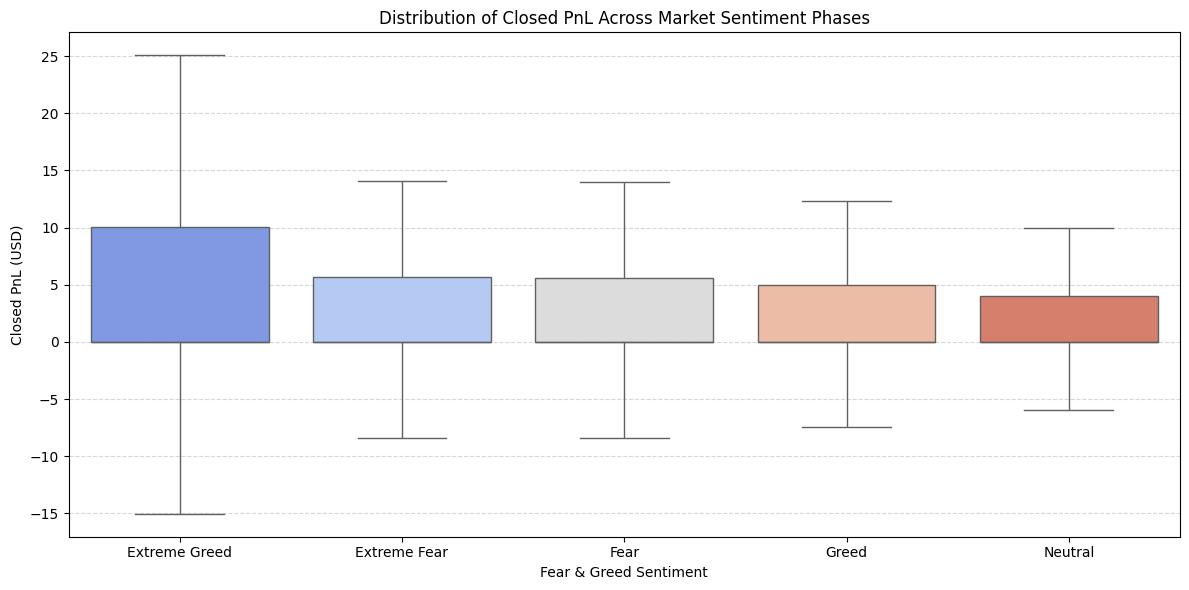

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(data=merged_df, x='Classification', y='Closed PnL', showfliers=False, palette='coolwarm')

plt.title('Distribution of Closed PnL Across Market Sentiment Phases')
plt.ylabel('Closed PnL (USD)')
plt.xlabel('Fear & Greed Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot
plt.savefig('sentiment_pnl_distribution.png', dpi=300)
plt.show()